In [44]:
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split


In [9]:
hst_data = pd.read_csv("hashtable.csv")
hst_data.head()

,trials,size,time
0,1000,100000,0.002346
1,1100,100000,0.002563
2,1200,100000,0.002849
3,1300,100000,0.003034
4,1400,100000,0.003335


<Axes: xlabel='trials', ylabel='time'>

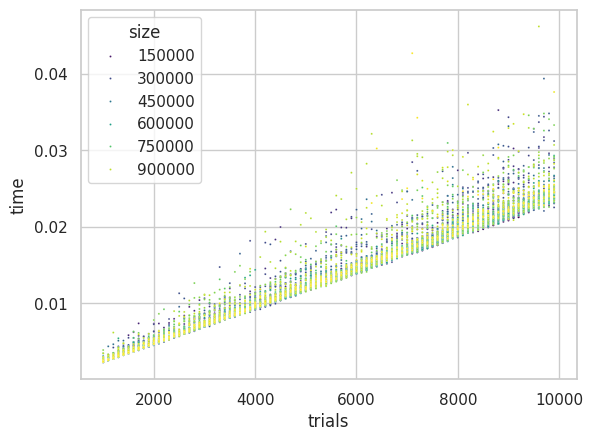

In [18]:
# plot time vs. trials, color by size

pointsize = 2.0

sns.scatterplot(
    x="trials",
    y="time",
    hue="size",
    data=hst_data,
    palette="viridis",
    s=pointsize,
)

<Axes: xlabel='size', ylabel='trials'>

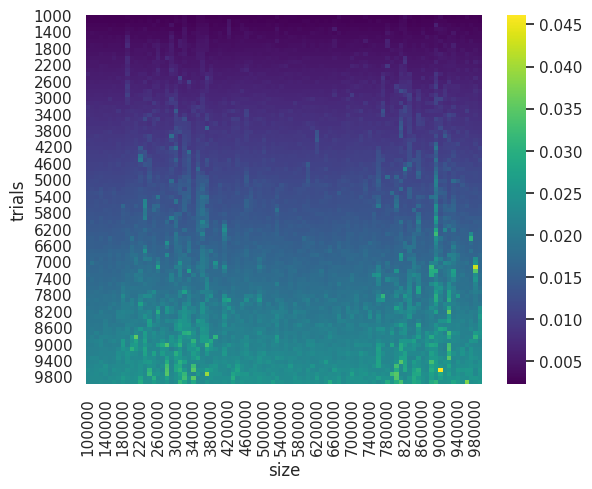

In [ ]:
# heatmap of time vs. trials and size
pivot_data = hst_data.pivot(index="trials", columns="size", values="time")
sns.heatmap(pivot_data, cmap="viridis")

In [ ]:
# do linear regression for time vs. trials, condition on size

train_sample, test_sample = train_test_split(hst_data, test_size=0.2, random_state=42)

formula = "time ~ trials + size + trials:size + 1 + C(size)"
model = sm.OLS.from_formula(formula, data=train_sample)
results = model.fit()
print(results.summary())

# test predictions
test_sample["predictions"] = results.predict(test_sample)
test_sample["residuals"] = test_sample["time"] - test_sample["predictions"]

# RMS error
rms_error = (test_sample["residuals"] ** 2).mean() ** 0.5
print(f"RMS error: {rms_error}")


                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                 3.751e+04
Date:                Tue, 25 Mar 2025   Prob (F-statistic):               0.00
Time:                        16:25:31   Log-Likelihood:                 32522.
No. Observations:                6480   AIC:                        -6.504e+04
Df Residuals:                    6476   BIC:                        -6.501e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.0002      0.000     -1.867      